## Descripción
### Fundamentos de Data Science

Analizando la Rotación de Clientes en Telecomunicaciones

### Requisitos

Tu tarea es limpiar y explorar un dataset para los ejecutivos de una empresa de telecomunicaciones que describe tendencias en la rotación de sus clientes.

In [84]:
#Librerías principales
import pandas as pd
import numpy as np

#Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración visual de los gráficos en tamaño
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5) #al usar positron necesito las figuras queden establecidas en tamaño tanto para mi código como para quien lo ve, ya que a veces a moi se me ven pequeñas y a otras personas tremendas.

### Carga y exploración inicial de datos

In [85]:
import pandas as pd

# Carga data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head (10) #mostrar las primeras 10 filas del data frame

#Exploración

print("-"*100)
df_shape = df.shape
print(df_shape) # muestra las dimensiones del dataset

df_tail = df.tail(10) 
print("-"*100)
print(df_tail) #muestra las primeras 5 filas

print("-"*100)
df_info = df.info()
print(df_info) #muestra la información de la tabla

print("-"*100)
df_describe = df.describe()
print(df_describe) #muestra los descriptivos de la tabla

df_types = df.dtypes
print("-"*100)
print(df_types) #muestra conteo de datos


# Valores faltantes
print("-"*100)
df_insull = df.isnull().sum()
print(df_insull)


----------------------------------------------------------------------------------------------------
(7043, 21)
----------------------------------------------------------------------------------------------------
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7033  9767-FFLEM    Male              0      No         No      38   
7034  0639-TSIQW  Female              0      No         No      67   
7035  8456-QDAVC    Male              0      No         No      19   
7036  7750-EYXWZ  Female              0      No         No      12   
7037  2569-WGERO  Female              0      No         No      72   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneServic

### Limpieza de datos con Python:
Identificar y solucionar cualquier valor duplicado.
a) Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

b) Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).

c) Identificar y solucionar cualquier valor faltante en el dataset. 

d) Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.

e) Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).

In [86]:
# Convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verificar cambios
df["TotalCharges"].dtype

# Verificar valores faltantes nuevamente
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Segun la info descrpitiva se ve la columna Total Charge no es númércia por lo que es necesario antes de eliminar duplicados, iniciar con la conversión a float. Además se detectaron 11 NA, los cuales corresponden al 0.15% del total de los valores de la columna. Posterior a la eliminación de duplicados se analizará qué método de imputación o rescate de NA se utilizará. 

In [87]:
#Ahora se continúa con la limpieza de datos
# Revisar duplicados
print("-"*100)
df_duplicated = df.duplicated().sum()
print(df_duplicated)

----------------------------------------------------------------------------------------------------
0


In [88]:
#Confirmación de tipo de datos según dictionario
print("-"*100)
df_dtypes = (df.dtypes)
print(df_dtypes)

----------------------------------------------------------------------------------------------------
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


Se encontraron 0 duplicados en la data. Se verificó que todas las variables coincidan con lo esperado según el diccionario de datos de la página web y hay diferencias en str y boleanos, sin embargo se mantienen variables categóricas y numércias que no interfieren en el análisis y para tal caso se deben considerar si se requiere análisis detallado de esas variables. Se Procede al rescate o eliminación de los valores faltantes NA. Pero antes, se verá mínimo y máximo y la distribución de la columna para ver método es más conveniente.

In [89]:
#mínimo y máximo para la columnas 
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    print(f"\nVariable: {col}")
    print("Mínimo:", df[col].min())
    print("Máximo:", df[col].max())


Variable: SeniorCitizen
Mínimo: 0
Máximo: 1

Variable: tenure
Mínimo: 0
Máximo: 72

Variable: MonthlyCharges
Mínimo: 18.25
Máximo: 118.75

Variable: TotalCharges
Mínimo: 18.8
Máximo: 8684.8


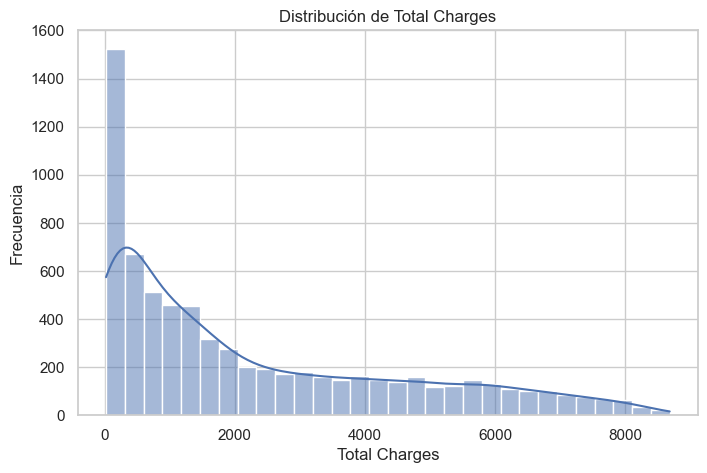

In [90]:
# Distribución de TotalCharges

sns.histplot(df["TotalCharges"], bins=30, kde=True)

plt.title("Distribución de Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frecuencia")

plt.show()

Tal como se evidencia en el gráfico una distribución no normal con una fuerte asimetría positiva, cola hacia la derecha y presencia de valores altos. Se utilizará dophna para considerar solo las celdas con valores existentes en la variable TotalCharges debido a que la cantidad de valores faltantes era mínima solo 11 (equivalente al 0,15%). Se descarta utilización de la media, porque puede verse afectada por clientes con cargos totales muy altos. Además, la cantidad de valores faltantes era mínima menor al 5%.

In [91]:
# Eliminar filas con valores faltantes
df = df.dropna()

# Verificar valores faltantes
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Exploración de datos con Python:
a) Crear dos tipos diferentes de visualizaciones exploratorias univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

a) Crear dos tipos diferentes de visualizaciones exploratorias multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

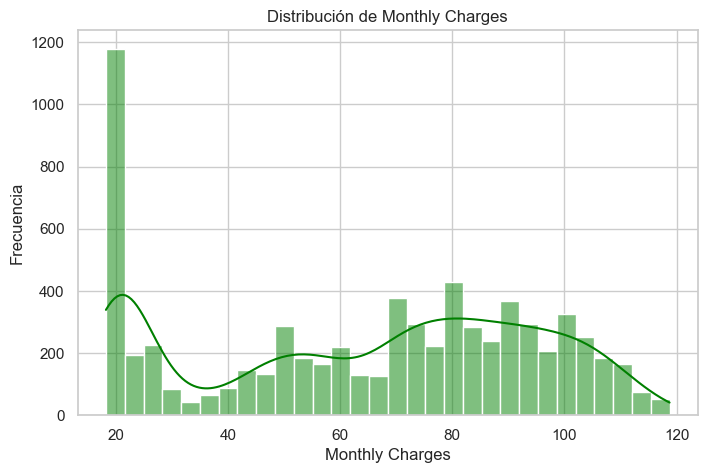

In [92]:
#Exploración de visualización exploratoria (Visualización univariada 1)
#Histograma Monthly charges 
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="green")

plt.title("Distribución de Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frecuencia")

plt.show()

El histograma muestra que la mayoría de los clientes paga cargos mensuales bajos, concentrados entre los 20 y 30 dólares. A medida que el monto aumenta, la cantidad de clientes disminuye, lo que se refleja en barras cada vez más pequeñas hacia la derecha. La curva suavizada confirma esta tendencia, con un gran pico en los valores bajos y una cola que se extiende hacia los valores altos. En este sentido, la base de clientes está formada principalmente por quienes contratan planes económicos, mientras que los planes más caros son menos frecuentes.

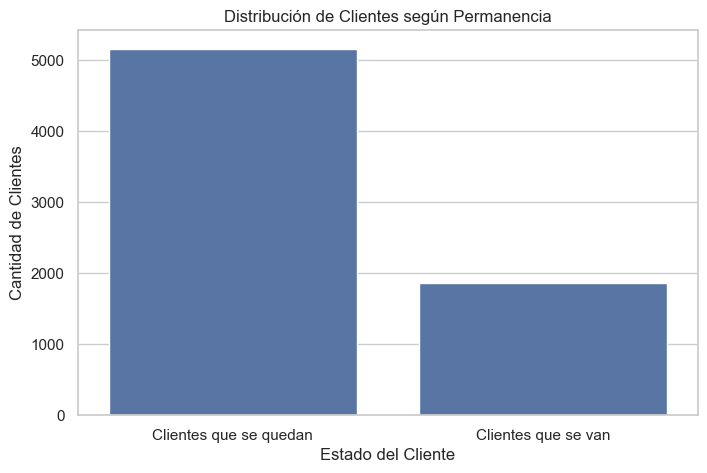

In [93]:
#Plot distribución de clientes con Churn (visualización univariada 2)
# Reemplazar valores de Churn
df["Churn_Label"] = df["Churn"].replace({
    "Yes": "Clientes que se van",
    "No": "Clientes que se quedan"
})

# Gráfico
sns.countplot(x="Churn_Label", data=df)

plt.title("Distribución de Clientes según Permanencia")
plt.xlabel("Estado del Cliente")
plt.ylabel("Cantidad de Clientes")

plt.show()

La mayoría de los clientes no abandonan la empresa. Sin embargo, existe una cantidad considerable de clientes que sí cancelan el servicio, lo que hace relevante analizar los factores asociados a ello (churn)

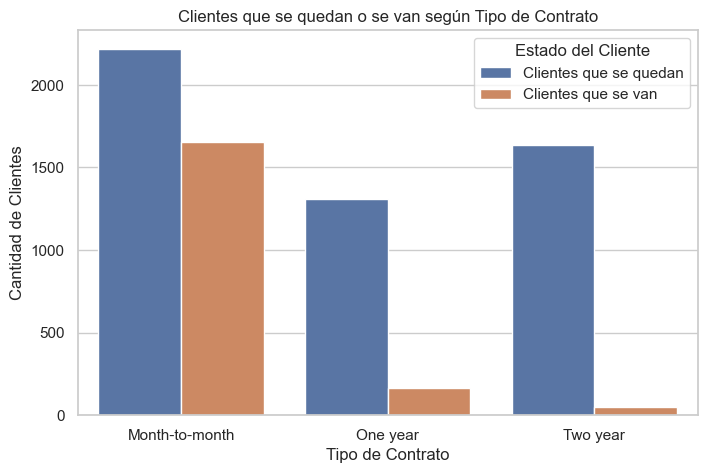

In [94]:
# Reemplazar valores de Churn
df["Churn_Label"] = df["Churn"].replace({
    "Yes": "Clientes que se van",
    "No": "Clientes que se quedan"
})

# Gráfico
sns.countplot(x="Contract", hue="Churn_Label", data=df)

plt.title("Clientes que se quedan o se van según Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")
plt.legend(title="Estado del Cliente")

plt.show()

El análisis evidencia que los clientes con contratos mes a mes presentan una mayor tasa de abandono, mientras que aquellos con contratos de uno o dos años muestran una menor cantidad de bajas. Lo que indica que la duración del contrato es un factor relevante en la retención de clientes.

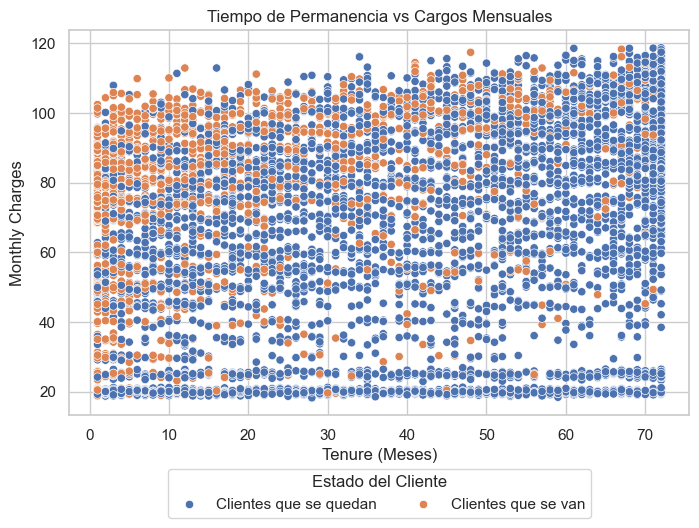

In [95]:
# Tenure vs Monthly Charges (Visualización multivariada 2)
# Reemplazar valores de Churn
sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue="Churn_Label",
    data=df
)

plt.title("Tiempo de Permanencia vs Cargos Mensuales")
plt.xlabel("Tenure (Meses)")
plt.ylabel("Monthly Charges")

# Leyenda debajo del gráfico
plt.legend(
    title="Estado del Cliente",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

plt.show()

El gráfico muestra la relación entre el tiempo de permanencia de los clientes en la empresa (tenure) y los cargos mensuales (Monthly Charges), diferenciando entre los clientes que permanecen y los que abandonan el servicio.
Se observa que la mayoría de los clientes permanece en la compañía, especialmente aquellos con mayor tiempo de permanencia. A medida que aumenta la antigüedad del cliente, predominan claramente los clientes que se quedan en comparación con los que abandonan el servicio.
Además, el gráfico sugiere que los clientes con cargos mensuales más bajos tienden a mantenerse con mayor frecuencia en la empresa, ya que en esos niveles se observa una mayor concentración de clientes que permanecen. En contraste, en los rangos de cargos mensuales más altos existe una mayor dispersión y presencia de clientes que abandonan el servicio.
En conclusión, el tiempo de permanencia parece ser un factor importante en la retención de clientes y, aunque los cargos mensuales no determinan completamente el abandono, los clientes con pagos más bajos muestran una tendencia mayor a permanecer en la compañía.

## Conclusiones Generales
El análisis exploratorio realizado permitió identificar patrones relevantes en el comportamiento de los clientes y evaluar la calidad del dataset. En primer lugar, se observó que los clientes con contratos de tipo mensual presentan una mayor tendencia al abandono, lo que sugiere que los compromisos de corto plazo están asociados a una menor retención. En contraste, los contratos de uno y dos años muestran una mayor estabilidad y permanencia de los clientes.
Asimismo, el tiempo de permanencia (tenure) demostró ser un factor importante en la retención, ya que los clientes con mayor antigüedad tienden a permanecer en la compañía, mientras que las bajas se concentran principalmente en los primeros meses de servicio. Además, se identificó que los clientes con cargos mensuales más bajos presentan una mayor tendencia a mantenerse en la empresa, mientras que en los cargos más altos existe una mayor presencia de clientes que abandonan el servicio.

# Referencias

- Documentación oficial de Pandas:
https://pandas.pydata.org/

- Documentación oficial de Seaborn:
https://seaborn.pydata.org/

- Documentación oficial de Matplotlib:
https://matplotlib.org/

- Plataforma Skillness – Core 5, 6, 8, 10, 11: Limpieza y visualización de datos.

- OpenAI ChatGPT utilizado únicamente como apoyo
conceptual y depuración de código durante el desarrollo
del análisis.

- Dataset: Telco Customer Churn Dataset
https://www.kaggle.com/

- IBM Sample Data Sets – Telco Customer Churn:
https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113